# Optional Lab: Cost Function for Logistic Regression

]

In [26]:
import numpy as np

import matplotlib.pyplot as plt


## Dataset 


In [29]:
X_train = np.array([[0.5, 1.5], [1,1], [1.5, 0.5], [3, 0.5], [2, 2], [1, 2.5]])  #(m,n)
y_train = np.array([0, 0, 0, 1, 1, 1])                                           #(m,)

We will use a helper function to plot this data. The data points with label $y=1$ are shown as red crosses, while the data points with label $y=0$ are shown as blue circles.

C:\Users\sampada\AppData\Local\Temp\ipykernel_10396\2565759127.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


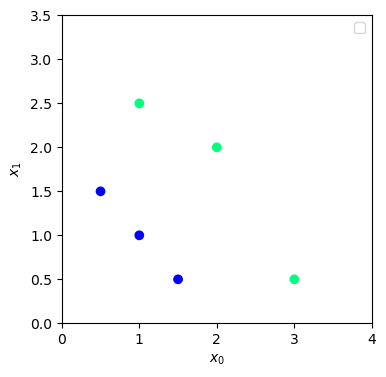

In [40]:

import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(4, 4))

# Plot y = 0 as blue circles
plt.scatter(X_train[:,0],X_train[0:,1],c=y_train,cmap='winter')

ax.axis([0, 4, 0, 3.5])
ax.set_xlabel('$x_0$')
ax.set_ylabel('$x_1$')
ax.legend()

plt.show()

<a name='ex-02'></a>
#### Code Description

The algorithm for `compute_cost_logistic` loops over all the examples calculating the loss for each example summing.

Note that the variables X and y are not scalar values but matrices of shape ($m, n$) and ($𝑚$,) respectively, where  $𝑛$ is the number of features and $𝑚$ is the number of training examples.


In [59]:


def sigmoid(z):
    """
    Compute the sigmoid of z.
    """
    return 1 / (1 + np.exp(-z))


In [61]:
def compute_cost_logistic(X, y, w, b):
    """
    Computes cost

    Args:
      X (ndarray (m,n)): Data, m examples with n features
      y (ndarray (m,)) : target values
      w (ndarray (n,)) : model parameters  
      b (scalar)       : model parameter
      
    Returns:
      cost (scalar): cost
    """

    m = X.shape[0]
    cost = 0.0
    for i in range(m):
        z_i = np.dot(X[i],w) + b
        f_wb_i = sigmoid(z_i)
        cost +=  -y[i]*np.log(f_wb_i) - (1-y[i])*np.log(1-f_wb_i)
             
    cost = cost / m
    return cost


Check the implementation of the cost function using the cell below.

In [64]:
w_tmp = np.array([1,1])
b_tmp = -3
print(compute_cost_logistic(X_train, y_train, w_tmp, b_tmp))

0.36686678640551745


**Expected output**: 0.3668667864055175

## Example
Now, let's see what the cost function output is for a different value of $w$. 

* In a previous lab, you plotted the decision boundary for  $b = -3, w_0 = 1, w_1 = 1$. That is, you had `w = np.array([-3,1,1])`.

* Let's say you want to see if $b = -4, w_0 = 1, w_1 = 1$, or `w = np.array([-4,1,1])` provides a better model.

Let's first plot the decision boundary for these two different $b$ values to see which one fits the data better.

* For $b = -3, w_0 = 1, w_1 = 1$, we'll plot $-3 + x_0+x_1 = 0$ (shown in blue)
* For $b = -4, w_0 = 1, w_1 = 1$, we'll plot $-4 + x_0+x_1 = 0$ (shown in magenta)

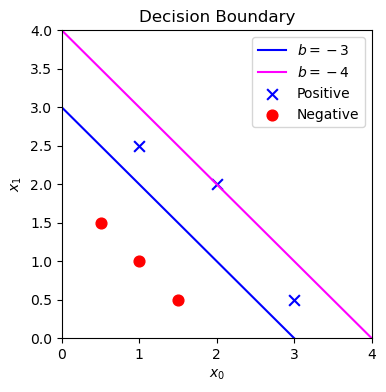

In [72]:
import matplotlib.pyplot as plt
import numpy as np

# Choose values between 0 and 6
x0 = np.arange(0, 6)

# Decision boundaries
x1 = 3 - x0
x1_other = 4 - x0

fig, ax = plt.subplots(figsize=(4, 4))

# Plot decision boundaries
ax.plot(x0, x1, color="blue", label="$b=-3$")
ax.plot(x0, x1_other, color="magenta", label="$b=-4$")

# Plot training data
plot_data(X_train, y_train, ax)

ax.set_xlim(0, 4)
ax.set_ylim(0, 4)
ax.set_xlabel("$x_0$")
ax.set_ylabel("$x_1$")
ax.set_title("Decision Boundary")
ax.legend()

plt.show()


You can see from this plot that `w = np.array([-4,1,1])` is a worse model for the training data. Let's see if the cost function implementation reflects this.

In [75]:
w_array1 = np.array([1,1])
b_1 = -3
w_array2 = np.array([1,1])
b_2 = -4

print("Cost for b = -3 : ", compute_cost_logistic(X_train, y_train, w_array1, b_1))
print("Cost for b = -4 : ", compute_cost_logistic(X_train, y_train, w_array2, b_2))

Cost for b = -3 :  0.36686678640551745
Cost for b = -4 :  0.5036808636748461


**Expected output**

Cost for b = -3 :  0.3668667864055175

Cost for b = -4 :  0.5036808636748461


You can see the cost function behaves as expected and the cost for `w = np.array([-4,1,1])` is indeed higher than the cost for `w = np.array([-3,1,1])`